## Gradient Boosting Machines (Model)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
hit = pd.read_csv("hitters.csv")
df = hit.copy()
df = df.dropna()
dms = pd.get_dummies(df[["League", "Division", "NewLeague"]])
dms = dms.astype(int)
y = df["Salary"]
X_ = df.drop(["Salary", "League", "Division", "NewLeague"], axis = 1).astype("float64")
X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size = 0.25,
                                                    random_state = 42)

In [3]:
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0,1,1,1
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0,0,1,0
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0,1,0,1
4,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0,1,0,1
5,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0,0,1,0


In [4]:
gbm_model = GradientBoostingRegressor()

In [5]:
gbm_model.fit(X_train, y_train)

GradientBoostingRegressor()

In [6]:
gbm_model.get_params()

{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'squared_error',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

## Tahmin

In [7]:
y_pred = gbm_model.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(357.79340857951)

## Model Tuning

In [8]:
gbm_params = {
    'learning_rate' : [0.001,0.01,0.1,0.2],
    'max_depth' : [3,5,8,50,100],
    'n_estimators' : [200,500,1000,2000],
    'subsample' : [1,0.5,0.75]
}

In [9]:
gbm = GradientBoostingRegressor()
gbm_cv_model = GridSearchCV(gbm, gbm_params, cv = 10, n_jobs = -1, verbose = 2)
gbm_cv_model.fit(X_train, y_train)

Fitting 10 folds for each of 240 candidates, totalling 2400 fits


GridSearchCV(cv=10, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 8, 50, 100],
                         'n_estimators': [200, 500, 1000, 2000],
                         'subsample': [1, 0.5, 0.75]},
             verbose=2)

In [10]:
gbm_cv_model.best_params_

{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 1000, 'subsample': 0.5}

In [11]:
#final model

In [12]:
gbm_tuned = GradientBoostingRegressor(learning_rate = 0.1, 
                                      max_depth = 3, 
                                      n_estimators = 500, 
                                      subsample = 0.5)
gbm_tuned.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=500, subsample=0.5)

In [13]:
#final test hatası

In [14]:
y_pred = gbm_tuned.predict(X_test)

In [15]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(324.9746175772336)

In [16]:
#degisken onem duzeyleri

In [17]:
Importance = pd.DataFrame({"Importance" : gbm_tuned.feature_importances_*100},
                          index = X_train.columns)

Text(0.5, 0, 'Değişken Önem Düzeyleri')

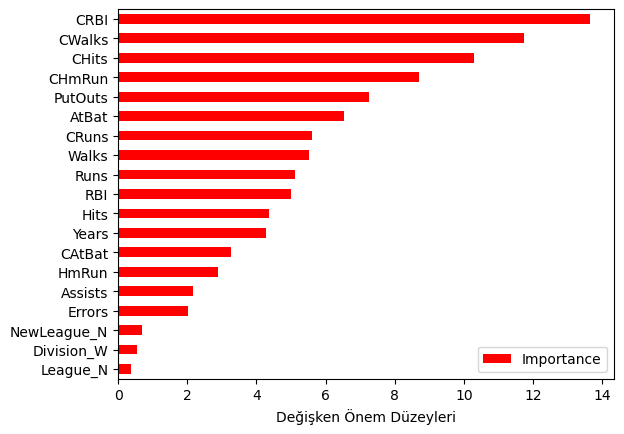

In [18]:
Importance.sort_values( by = "Importance",
                       axis = 0,
                       ascending = True).plot(kind = "barh", color = "r")

plt.xlabel("Değişken Önem Düzeyleri")